In [1]:
# Import all pacakges
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
from sklearn.metrics import balanced_accuracy_score, precision_score, average_precision_score, roc_auc_score, recall_score, cohen_kappa_score, matthews_corrcoef, f1_score
import shap
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

/Users/saraziadat/miniconda3/envs/bbb_exc_score_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED=15
ds = 'full_dataset'

plt.rcParams.update({'font.size': 15})
colors = ["#F35965", "#6BF178", "#3EA7FF", "#8633A8", "#30D5C8", "#DC8DC4"]

# "/Users/saraziadat/Desktop/bbb-exc-score/model_results/full_dataset/training_output_values_15_full_dataset_final.csv"
# "../training_shap_output_values_15_full_dataset_final.csv"

dataset_path = f'../datasets/b3db_drug_like_labelled.csv' #_ecfp_mordred_maccs_negative
# outerfold_shap_vals_path = './results/training_shap_output_values.csv.csv'
outerfold_shap_vals_path = f'../model_results/{ds}/training_shap_output_values_{SEED}_{ds}_final.csv'

In [3]:
# Import Dataset
full_df = pd.read_csv(dataset_path)

smiles = full_df.loc[:, 'SMILES']
bbb_class = full_df.loc[:, 'Class']
logbb = full_df.loc[:, 'logBB']

starting_col = list(full_df.columns).index('Class') + 1
X_full = full_df.iloc[:, starting_col:]

bbb_class = np.array(bbb_class)
# bbb_class = (bbb_class+1)/2
logbb = np.array(logbb)

X_full = X_full.values
X_to_drop = pd.DataFrame(data=X_full, columns=list(full_df.columns)[starting_col:])
X_full_no_nan = X_to_drop.dropna(axis=1)
X_full_no_nan = X_full_no_nan.loc[:, X_full_no_nan.std() != 0]

X_all = X_full_no_nan.values

scaler = MinMaxScaler().fit(X_all)
X_scaled = scaler.transform(X_all)
df_scaled = pd.DataFrame(X_scaled)
# np.sum(np.where(np.std(X_scaled, axis=0)==0,1, 0))


3041
<class 'numpy.float64'>


/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/743934449.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(type(top_features['mean_abs_shap'][0]))


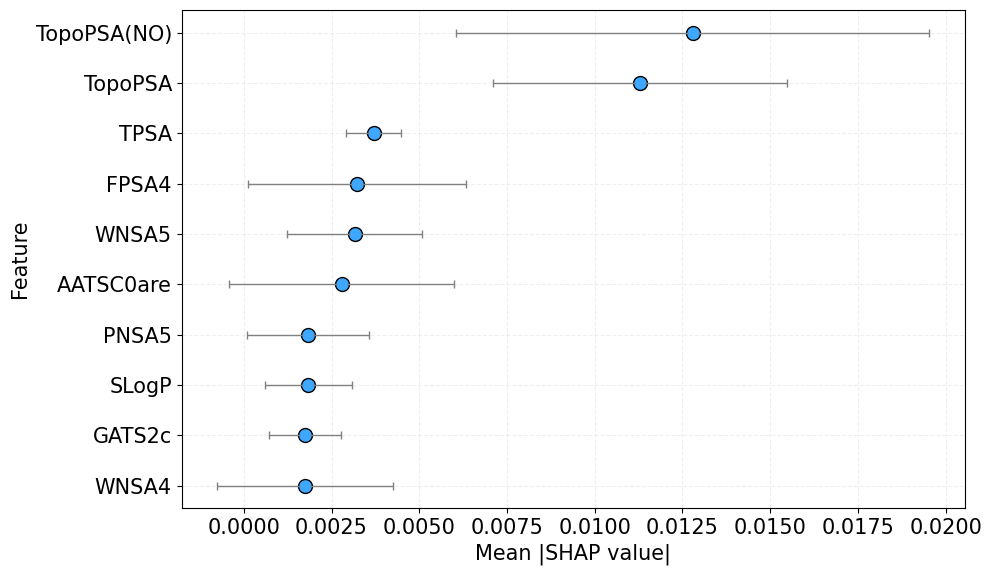

These features correspond to the following columns: 
 TopoPSA(NO)    2830
TopoPSA        2831
TPSA           2446
FPSA4          2429
WNSA5          2435
AATSC0are      2338
PNSA5          2410
SLogP          2828
GATS2c         2372
WNSA4          2434
Name: feature_id, dtype: int64


In [4]:
shap_vals_fold = pd.read_csv(outerfold_shap_vals_path).iloc[:,1:]
shap_means = np.mean(np.abs(shap_vals_fold), axis=0)
shap_std = np.std(np.abs(shap_vals_fold), axis=0)

print(len(shap_means))

shap_importance_df = pd.DataFrame({
    'feature': list(X_full_no_nan.columns),
    'feature_id': range(len(list(X_full_no_nan.columns))),
    'mean_abs_shap': np.abs(shap_means),
    'std_shap': shap_std
}).sort_values('mean_abs_shap', ascending=False)


top_n = 10
top_features = shap_importance_df.head(top_n)

plt.figure(figsize=(10, 6))

print(type(top_features['mean_abs_shap'][0]))

plt.scatter(
    top_features['mean_abs_shap'],
    top_features['feature'],
    color=colors[2],
    s=100,
    edgecolor='k'
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")


plt.gca().invert_yaxis()  # Highest importance at top
plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()


plt.errorbar(
    top_features['mean_abs_shap'],
    top_features['feature'],
    xerr=top_features['std_shap'],
    fmt='o',
    color=colors[2],
    ecolor='gray',
    elinewidth=1,
    capsize=3
)

plt.savefig(f'../model_evaluation/{ds}/feature_importance.png', dpi=300)
plt.show()

print("These features correspond to the following columns: \n", top_features['feature_id'])

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/4102289535.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      4.4088
Link Function:                     IdentityLink Log Likelihood:                                  -983.4673
Number of Samples:                          761 AIC:                                             1977.7523
                                                AICc:                                            1977.8442
                                                GCV:                                                0.3513
                                                Scale:                                              0.3476
                                                Pseudo R-Squared:                                   0.3676
Feature Function                  Lam

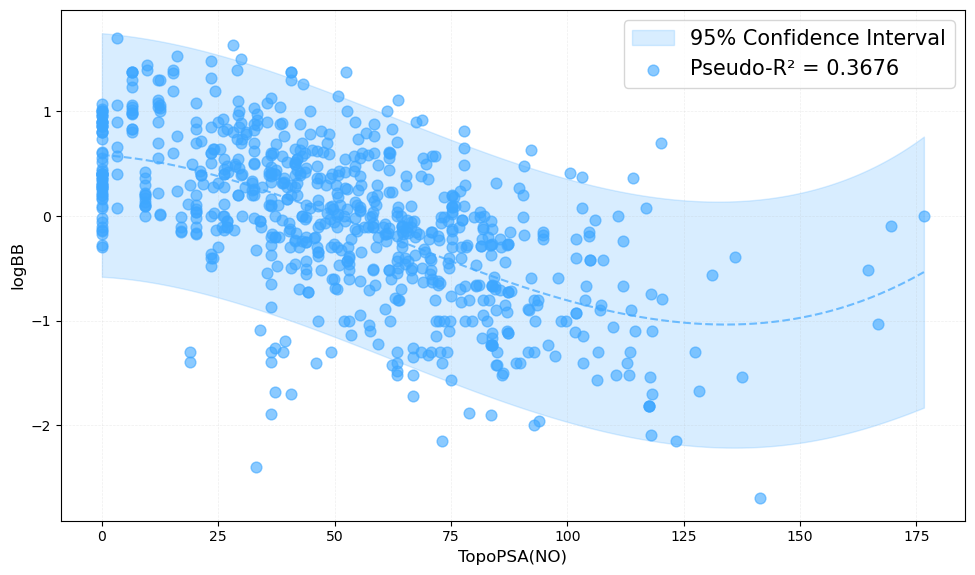

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/4102289535.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      4.4671
Link Function:                     IdentityLink Log Likelihood:                                   -974.416
Number of Samples:                          761 AIC:                                             1959.7663
                                                AICc:                                            1959.8601
                                                GCV:                                                0.3616
                                                Scale:                                              0.3577
                                                Pseudo R-Squared:                                   0.3492
Feature Function                  Lam

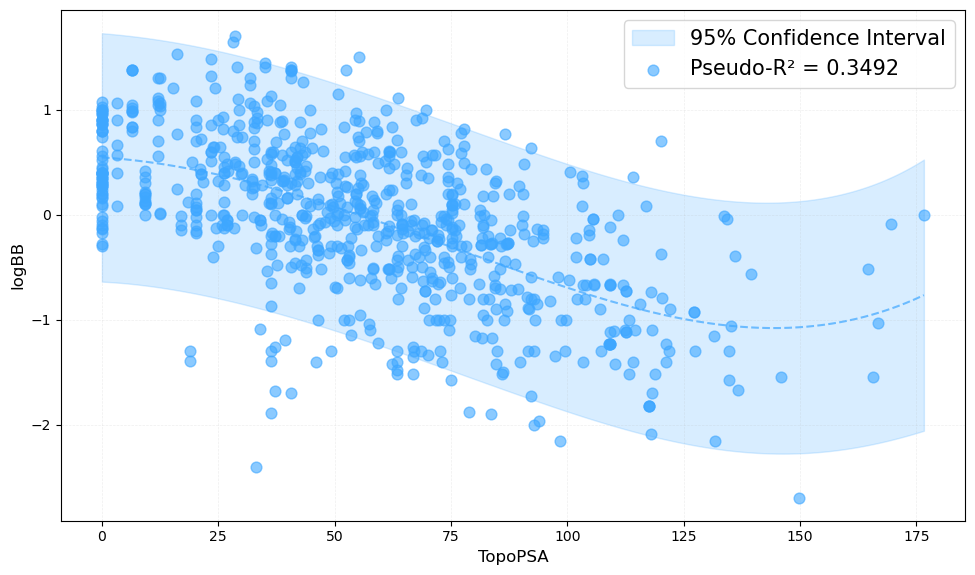

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/4102289535.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      4.7471
Link Function:                     IdentityLink Log Likelihood:                                   -955.484
Number of Samples:                          761 AIC:                                              1922.462
                                                AICc:                                            1922.5648
                                                GCV:                                                0.3887
                                                Scale:                                              0.3843
                                                Pseudo R-Squared:                                   0.3012
Feature Function                  Lam

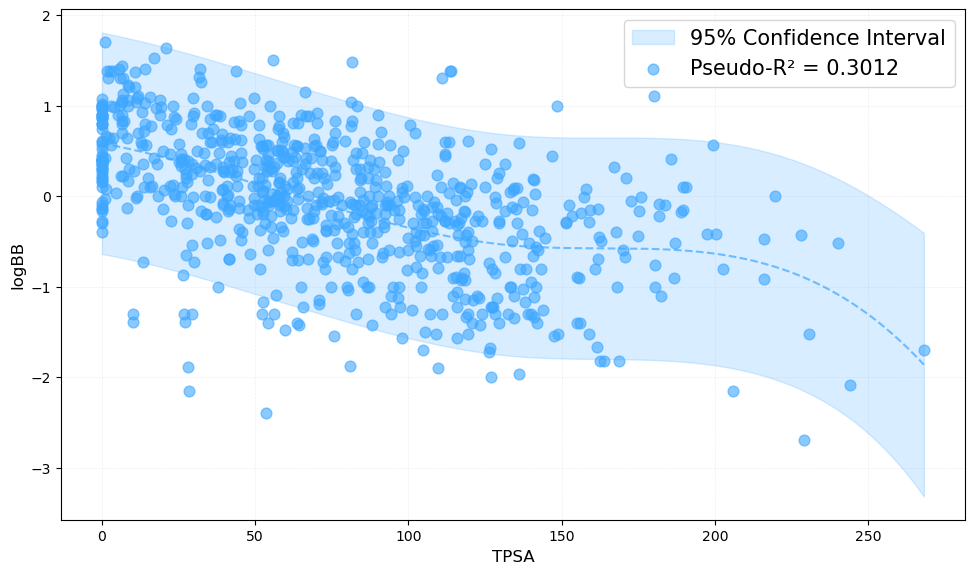

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/4102289535.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      3.3321
Link Function:                     IdentityLink Log Likelihood:                                  -933.9555
Number of Samples:                          761 AIC:                                             1876.5751
                                                AICc:                                            1876.6362
                                                GCV:                                                0.4511
                                                Scale:                                              0.4475
                                                Pseudo R-Squared:                                   0.1846
Feature Function                  Lam

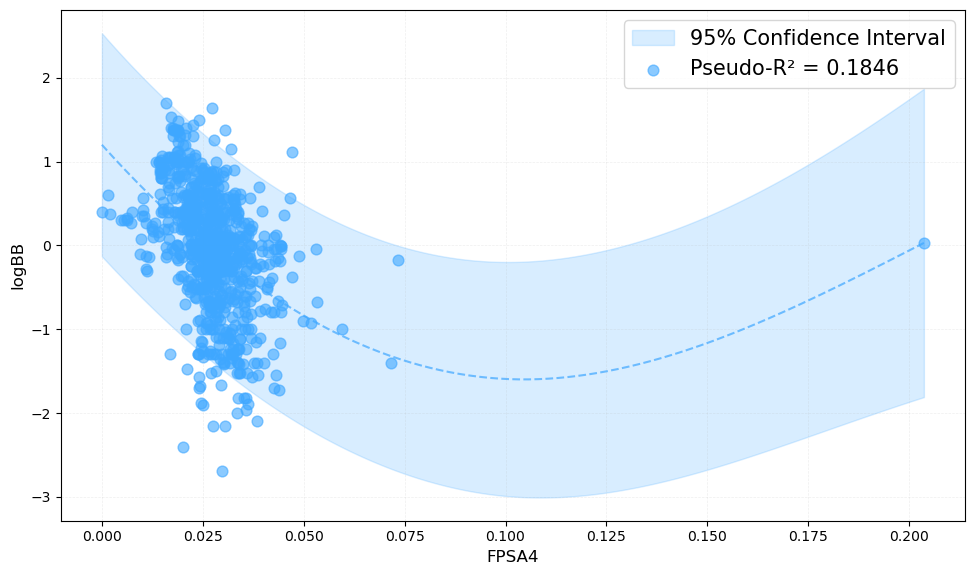

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/4102289535.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      2.0032
Link Function:                     IdentityLink Log Likelihood:                                  -935.0273
Number of Samples:                          761 AIC:                                              1876.061
                                                AICc:                                            1876.0927
                                                GCV:                                                0.4519
                                                Scale:                                              0.4497
                                                Pseudo R-Squared:                                   0.1792
Feature Function                  Lam

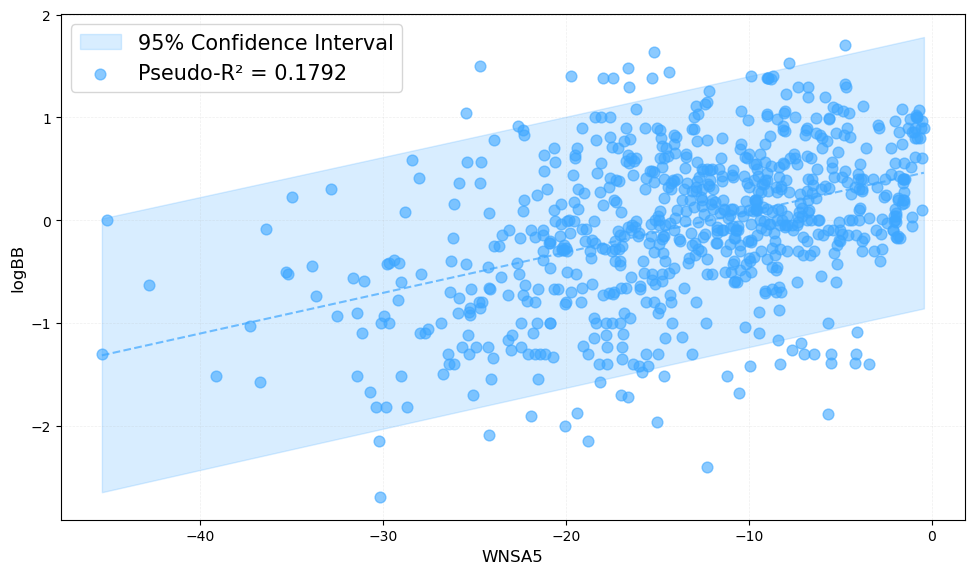

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/4102289535.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      4.8657
Link Function:                     IdentityLink Log Likelihood:                                   -934.555
Number of Samples:                          761 AIC:                                             1880.8414
                                                AICc:                                            1880.9482
                                                GCV:                                                0.4418
                                                Scale:                                              0.4367
                                                Pseudo R-Squared:                                    0.206
Feature Function                  Lam

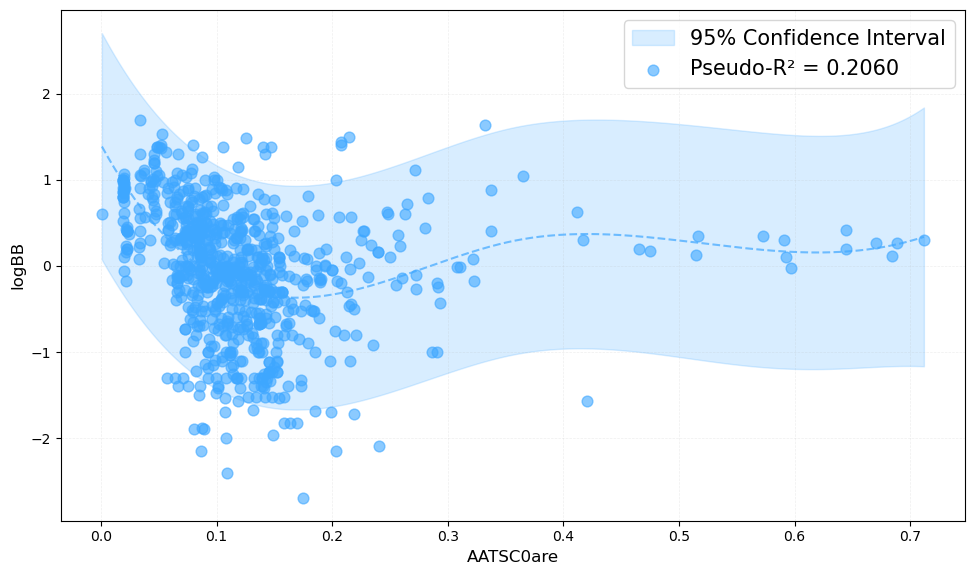

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/4102289535.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                       2.003
Link Function:                     IdentityLink Log Likelihood:                                   -937.889
Number of Samples:                          761 AIC:                                              1881.784
                                                AICc:                                            1881.8158
                                                GCV:                                                0.4385
                                                Scale:                                              0.4365
                                                Pseudo R-Squared:                                   0.2034
Feature Function                  Lam

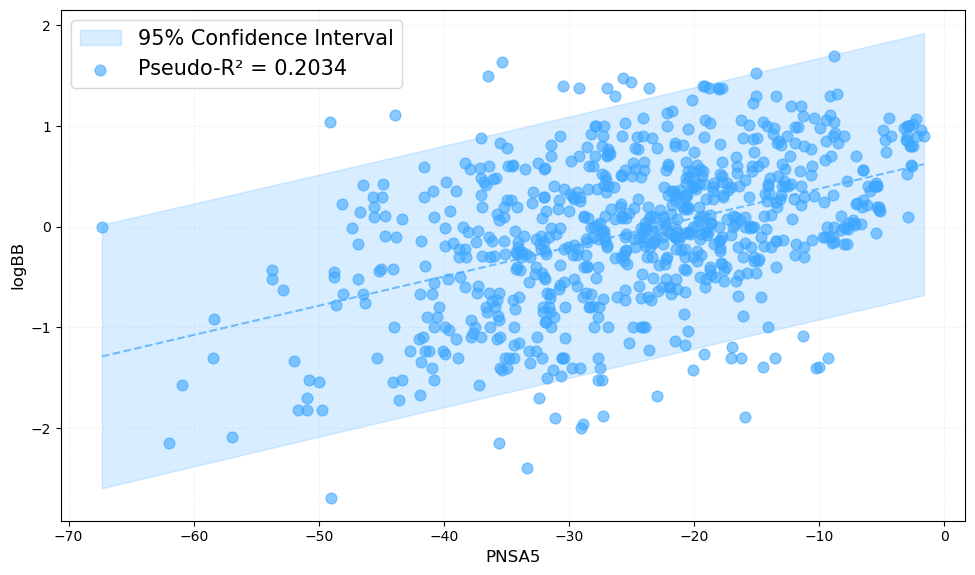

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/4102289535.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      2.3225
Link Function:                     IdentityLink Log Likelihood:                                  -930.6245
Number of Samples:                          761 AIC:                                              1867.894
                                                AICc:                                            1867.9319
                                                GCV:                                                0.5104
                                                Scale:                                              0.5076
                                                Pseudo R-Squared:                                    0.074
Feature Function                  Lam

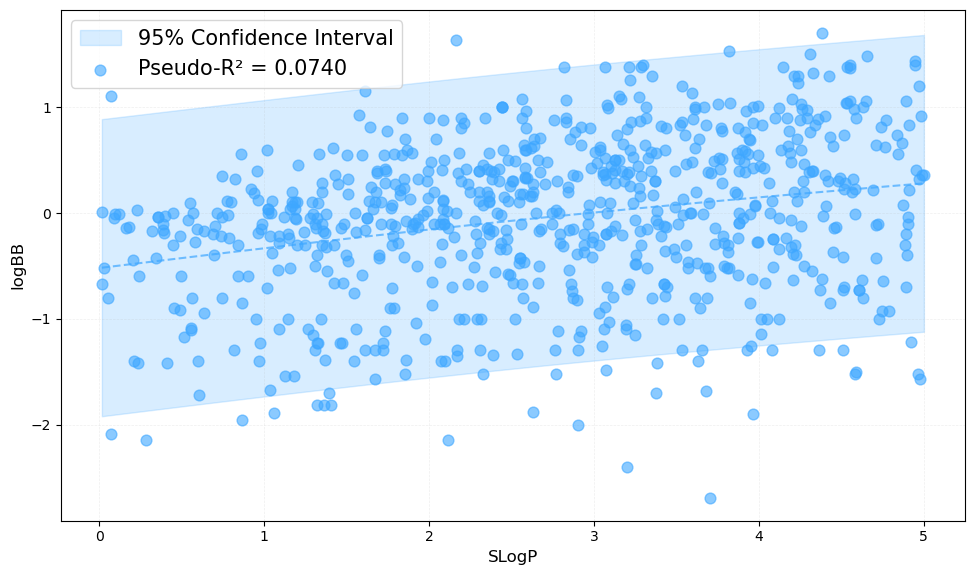

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/4102289535.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      3.2427
Link Function:                     IdentityLink Log Likelihood:                                  -930.3998
Number of Samples:                          761 AIC:                                             1869.2849
                                                AICc:                                            1869.3437
                                                GCV:                                                0.4791
                                                Scale:                                              0.4754
                                                Pseudo R-Squared:                                   0.1337
Feature Function                  Lam

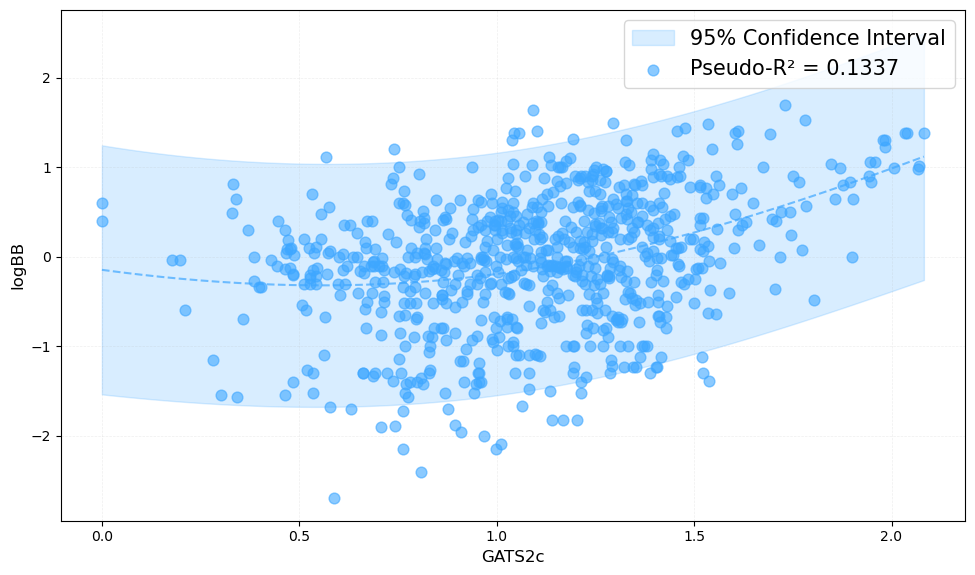

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/4102289535.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      2.3281
Link Function:                     IdentityLink Log Likelihood:                                  -932.8307
Number of Samples:                          761 AIC:                                             1872.3177
                                                AICc:                                            1872.3558
                                                GCV:                                                0.4639
                                                Scale:                                              0.4614
                                                Pseudo R-Squared:                                   0.1583
Feature Function                  Lam

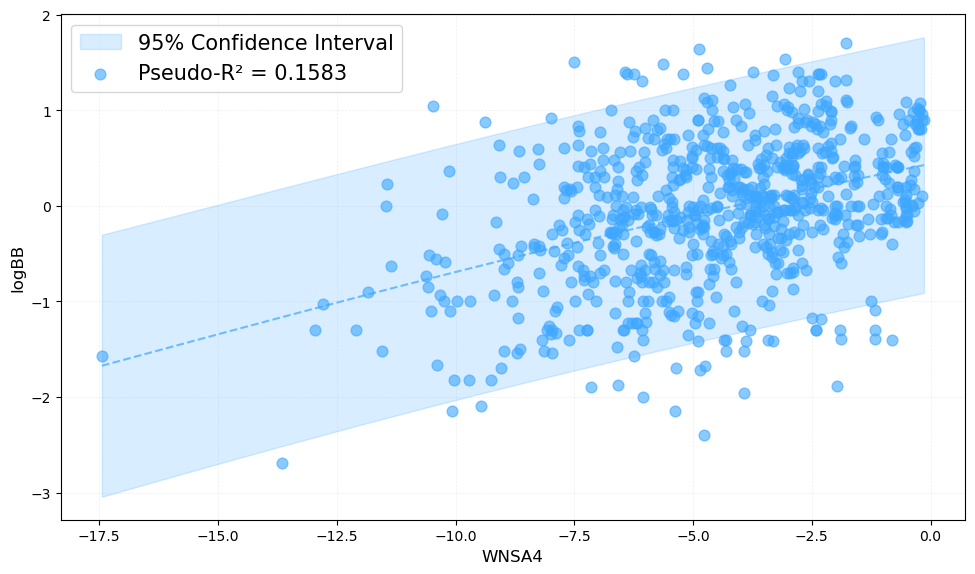

In [5]:
from pygam import LinearGAM, s, f, l
import numpy as np
import matplotlib.pyplot as plt

## defining rules – combinations: 
l_cols = top_features['feature_id']

gam = LinearGAM(s(0)+s(1)+s(2)+s(3)+s(4)+s(5)+s(6)+s(7)+s(8)+s(9)).fit(X_all[:, l_cols][~np.isnan(logbb)], logbb[~np.isnan(logbb)]) # 

for col_id, col in enumerate(l_cols): 
    gam = LinearGAM(n_splines=5).gridsearch(X_all[:, [col]][~np.isnan(logbb)], logbb[~np.isnan(logbb)]) # 
    XX = gam.generate_X_grid(term=0, n=500)

    
    pred = gam.prediction_intervals(XX, width=.95)
    gam.summary()
    pseudo_r2 = gam.statistics_['pseudo_r2']['explained_deviance']

    # Assuming XX, pred, X_all, logbb, and col are already defined
    fig, ax = plt.subplots(figsize=(10, 6))

    # 95% Confidence Interval shading
    ax.fill_between(XX[:, 0], pred[:, 0], pred[:, 1], 
                    alpha=0.2, color=colors[2], zorder=1, label="95% Confidence Interval") # label='95% CI', 
    ax.plot(XX, gam.predict(XX), '--', zorder=4, color=colors[2], alpha=0.7)

    # Scatter plot of actual data
    ax.scatter(X_all[:, col][~np.isnan(logbb)], 
            logbb[~np.isnan(logbb)], 
            facecolor=colors[2], 
            alpha=0.6, s=60, label=f'Pseudo-R\u00B2 = {pseudo_r2:.4f}', zorder=3) #edgecolor='k', 

    ax.grid(True, linestyle='--', linewidth=0.5, zorder=0, alpha=0.2)
    ax.set_xlabel(f'{list(X_full_no_nan.columns)[col]}', fontsize=12)
    ax.set_ylabel('logBB', fontsize=12)
    # props = dict(boxstyle='round', facecolor='white', edgecolor='lightgray')
    # ax.text(0.98, 0.95,f'Pseudo-R\u00B2 = {pseudors[col_id]}', bbox=props)

    # ax.set_title('Prediction with 95% Confidence Interval', fontsize=14)
    ax.legend()
    ax.tick_params(axis='both', labelsize=10)

    # Optional: Tight layout
    plt.tight_layout()
    plt.savefig(f'../model_evaluation/{ds}/regression_gams/regression_gam_{list(X_full_no_nan.columns)[col]}.png', dpi=300)

    plt.show()
    plt.close()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                        

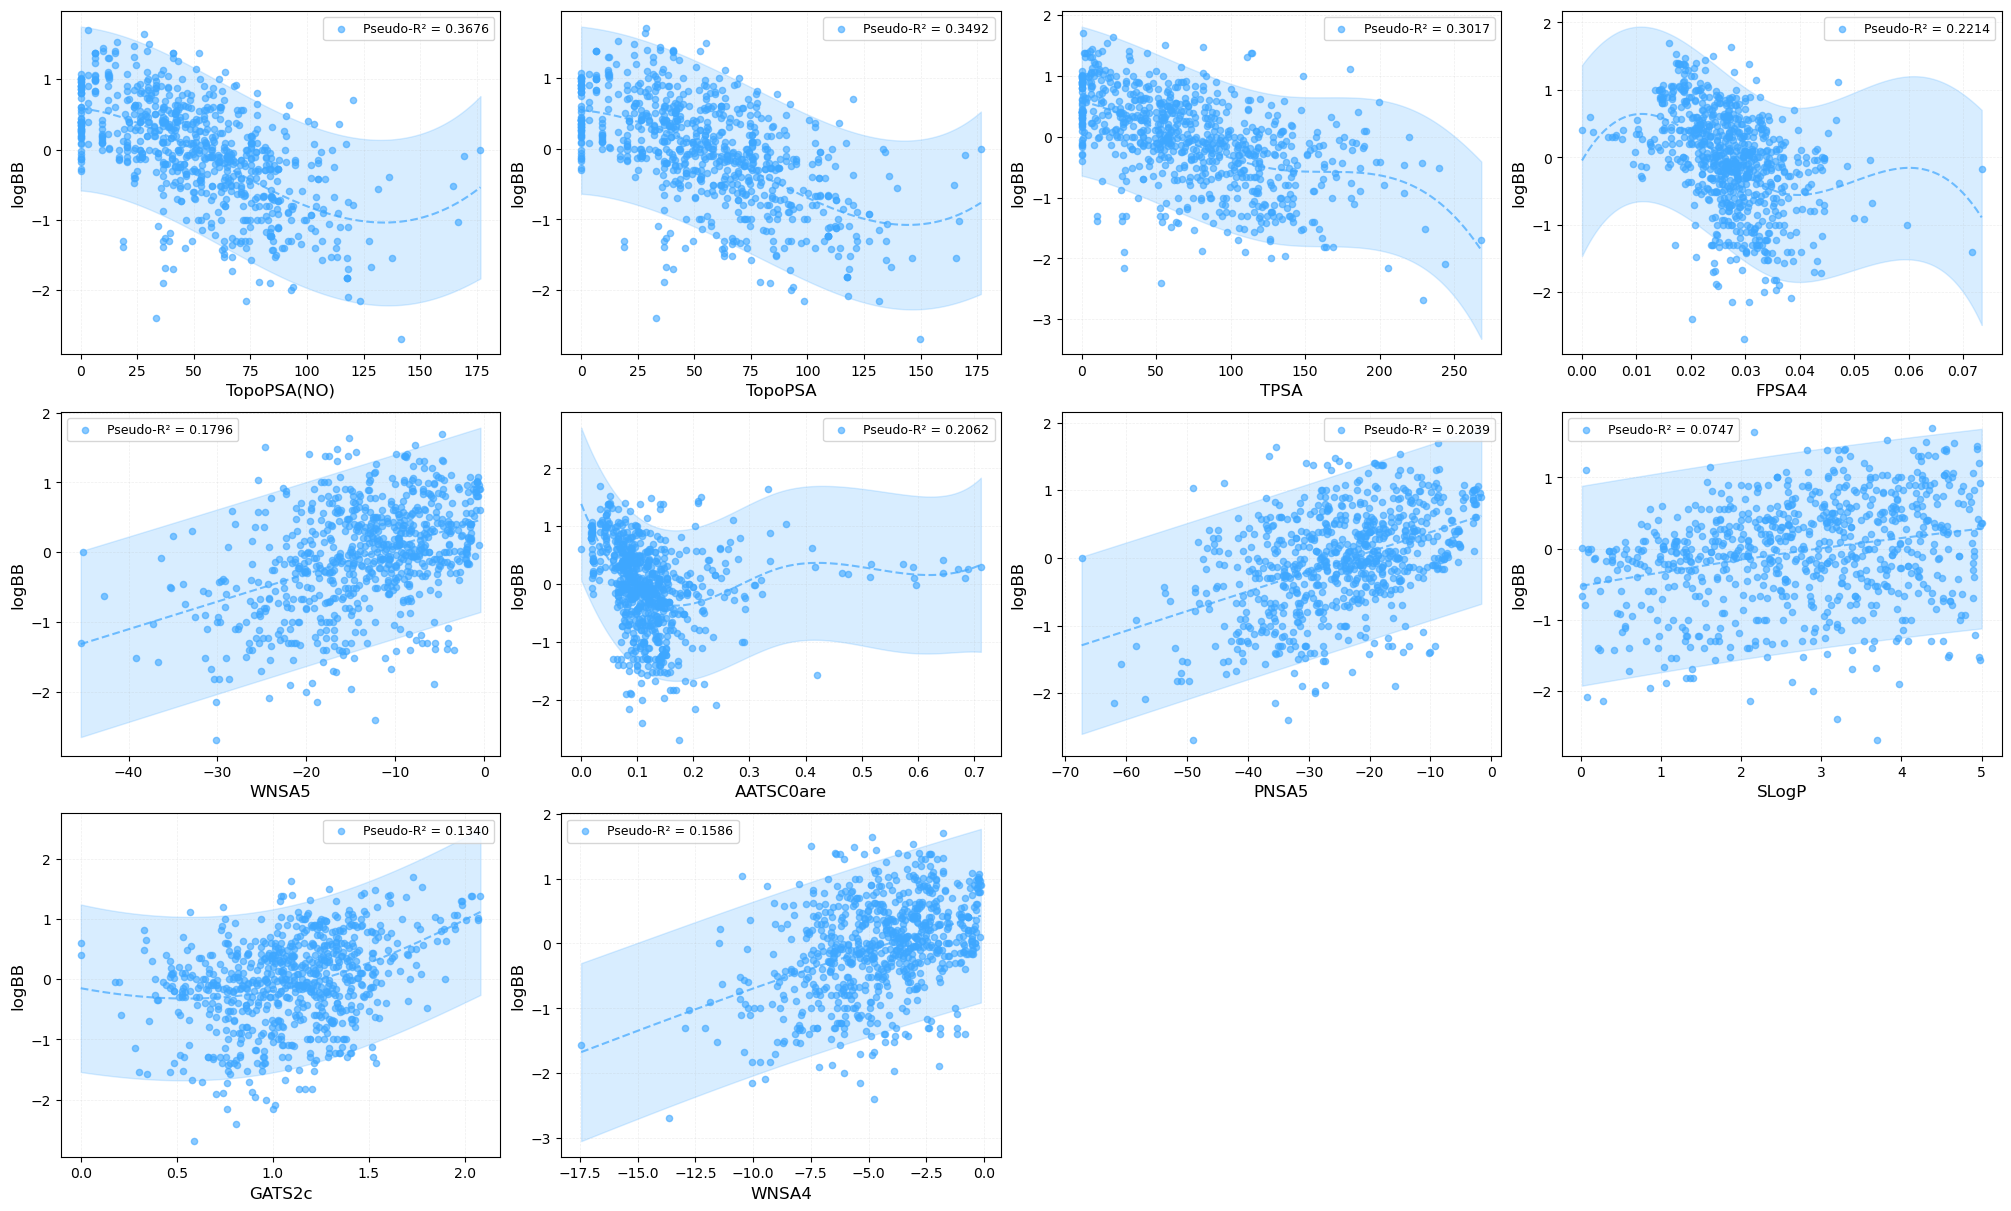

/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/1507463400.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  feature_indices=l_cols[subset],
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


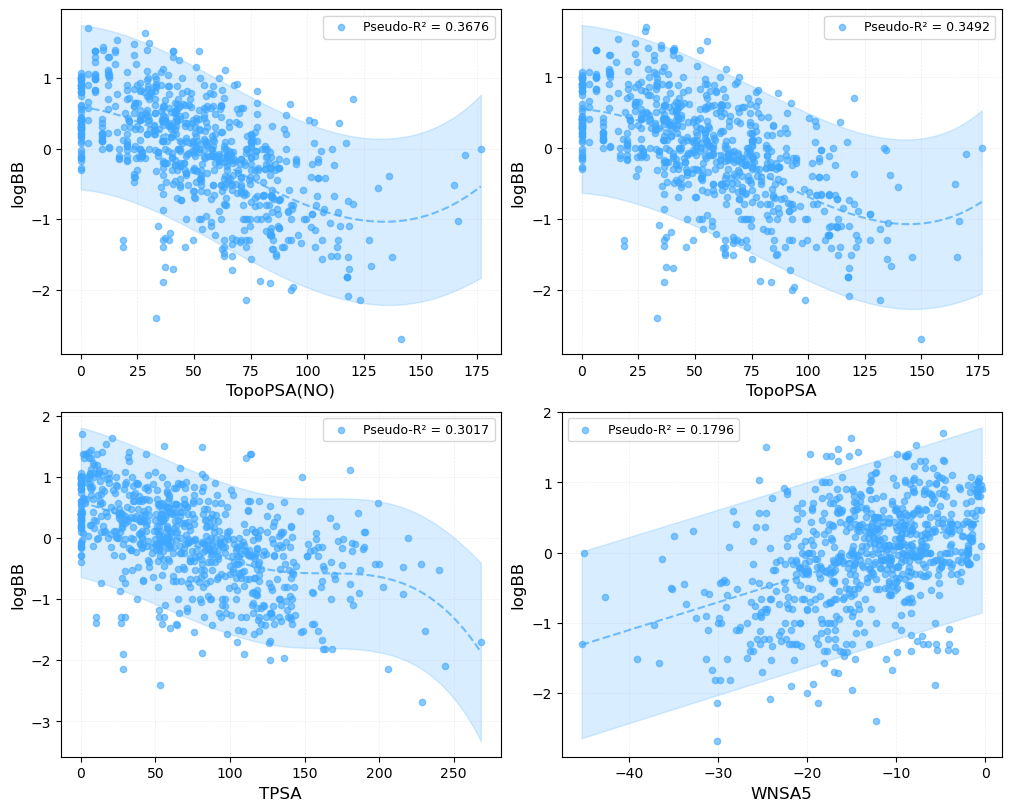

In [6]:
from pygam import LinearGAM, s
import numpy as np
import matplotlib.pyplot as plt

def plot_gam_panels(feature_indices, n_cols, title, save_path, colors, n_splines=5):
    """
    feature_indices: list of feature column indices to plot
    title: overall figure title
    save_path: path to save the figure
    colors: list of colors to use for plotting
    n_splines: number of splines for GAM
    """
    n_features = len(feature_indices)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), constrained_layout=True)
    axes = axes.flatten()
    
    for idx, col in enumerate(feature_indices):
        ax = axes[idx]

        X_subset = X_all[X_all[:, 2429]< 0.1]    
        logbb_subset = logbb[X_all[:, 2429] < 0.1]

        # Fit GAM for this feature
        gam = LinearGAM(n_splines=n_splines).gridsearch(X_subset[:, [col]][~np.isnan(logbb_subset)], logbb_subset[~np.isnan(logbb_subset)])
        # gam = LinearGAM(n_splines=n_splines).gridsearch(X_all[:, [col]][~np.isnan(logbb)], logbb[~np.isnan(logbb)])
        XX = gam.generate_X_grid(term=0, n=500)
        pred = gam.prediction_intervals(XX, width=0.95)
        pseudo_r2 = gam.statistics_['pseudo_r2']['explained_deviance']

        # 95% confidence interval
        ax.fill_between(XX[:, 0], pred[:, 0], pred[:, 1],
                        alpha=0.2, color=colors[2], zorder=1)
        # GAM fit line
        ax.plot(XX, gam.predict(XX), '--', color=colors[2], alpha=0.7, zorder=4)
        # Scatter of actual data
        ax.scatter(X_subset[:, col][~np.isnan(logbb_subset)],
                   logbb_subset[~np.isnan(logbb_subset)],
                   facecolor=colors[2], alpha=0.6, s=20,
                   label=f'Pseudo-R\u00B2 = {pseudo_r2:.4f}', zorder=3)
        # ax.scatter(X_all[:, col][~np.isnan(logbb)],
        #            logbb[~np.isnan(logbb)],
        #            facecolor=colors[2], alpha=0.6, s=20,
        #            label=f'Pseudo-R\u00B2 = {pseudo_r2:.4f}', zorder=3)

        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
        ax.set_xlabel(f'{list(X_full_no_nan.columns)[col]}', fontsize=12)
        ax.set_ylabel('logBB', fontsize=12)
        ax.legend(fontsize=9)
        ax.tick_params(axis='both', labelsize=10)

    # Remove any unused subplots
    for ax in axes[n_features:]:
        fig.delaxes(ax)

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


plot_gam_panels(
    feature_indices=l_cols[:10],
    n_cols=4,
    title='GAM Regression for All 10 Features',
    save_path=f'../model_evaluation/{ds}/regression_gams/gam_all_features.png',
    colors=colors
)


subset = [0,1,2,4] 
plot_gam_panels(
    feature_indices=l_cols[subset],
    n_cols=2,
    title='GAM Regression for Selected Features',
    save_path=f'../model_evaluation/{ds}/regression_gams/gam_selected_features.png',
    colors=colors
)


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |#######################

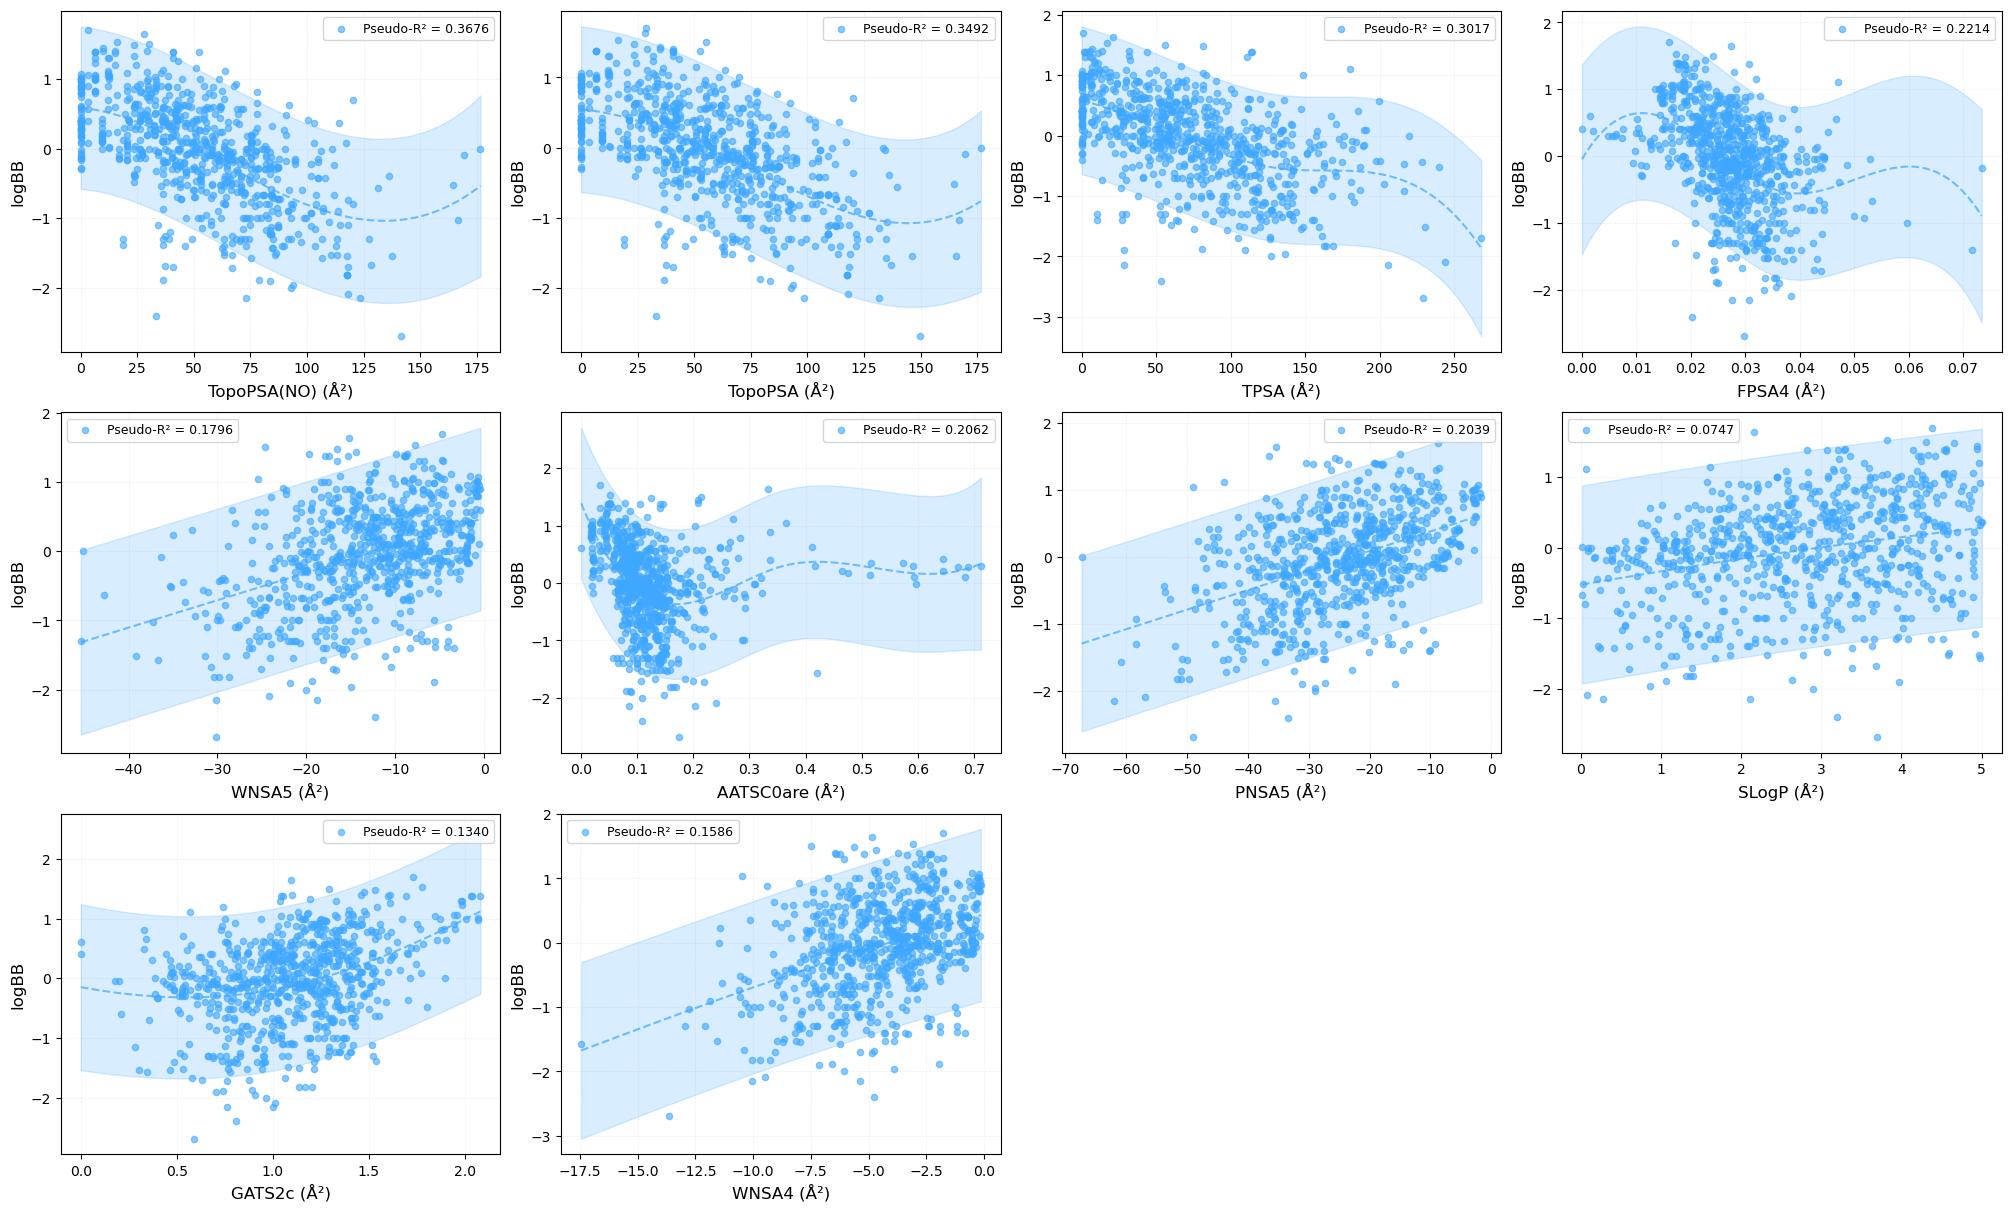

/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/3620173428.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  feature_indices=l_cols[subset],
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of

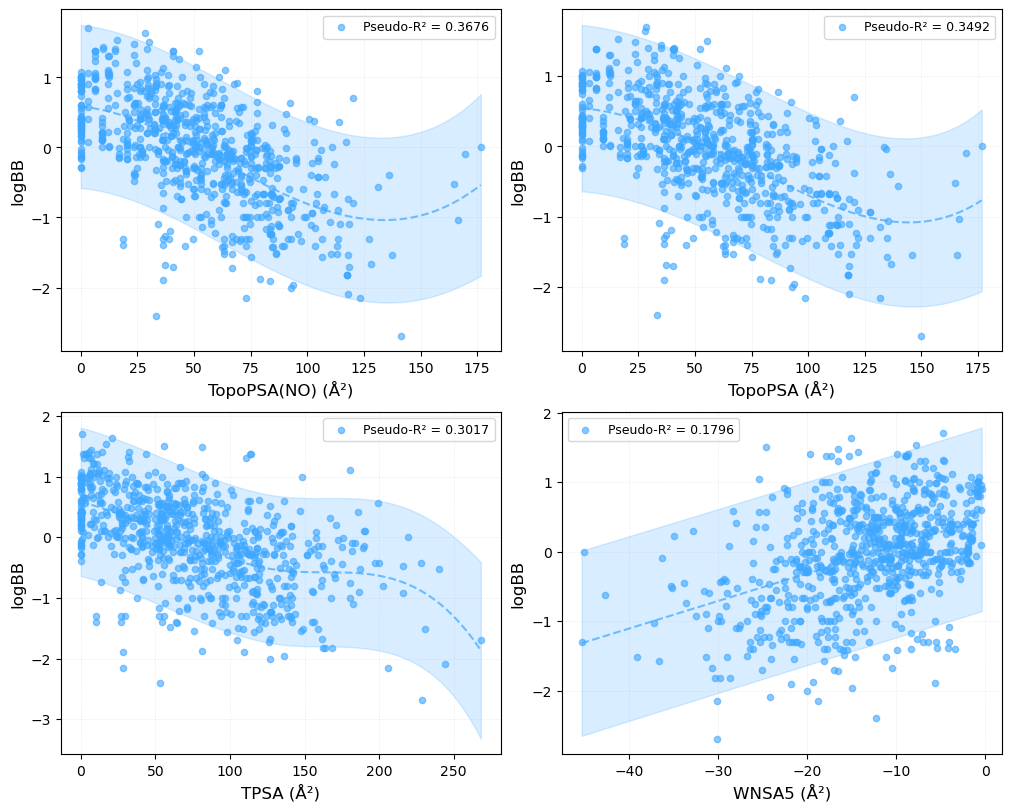

In [7]:
from pygam import LinearGAM, s
import numpy as np
import matplotlib.pyplot as plt

def plot_gam_panels(feature_indices, n_cols, title, save_path, colors, n_splines=5):
    """
    feature_indices: list of feature column indices to plot
    title: overall figure title
    save_path: path to save the figure
    colors: list of colors to use for plotting
    n_splines: number of splines for GAM
    """
    n_features = len(feature_indices)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), constrained_layout=True)
    axes = axes.flatten()
    
    for idx, col in enumerate(feature_indices):
        ax = axes[idx]

        X_subset = X_all[X_all[:, 2429]< 0.1]    
        logbb_subset = logbb[X_all[:, 2429] < 0.1]

        # Fit GAM for this feature
        gam = LinearGAM(n_splines=n_splines).gridsearch(X_subset[:, [col]][~np.isnan(logbb_subset)], logbb_subset[~np.isnan(logbb_subset)])
        # gam = LinearGAM(n_splines=n_splines).gridsearch(X_all[:, [col]][~np.isnan(logbb)], logbb[~np.isnan(logbb)])
        XX = gam.generate_X_grid(term=0, n=500)
        pred = gam.prediction_intervals(XX, width=0.95)
        pseudo_r2 = gam.statistics_['pseudo_r2']['explained_deviance']

        # 95% confidence interval
        ax.fill_between(XX[:, 0], pred[:, 0], pred[:, 1],
                        alpha=0.2, color=colors[2], zorder=1)
        # GAM fit line
        ax.plot(XX, gam.predict(XX), '--', color=colors[2], alpha=0.7, zorder=4)
        # Scatter of actual data
        ax.scatter(X_subset[:, col][~np.isnan(logbb_subset)],
                   logbb_subset[~np.isnan(logbb_subset)],
                   facecolor=colors[2], alpha=0.6, s=20,
                   label=f'Pseudo-R\u00B2 = {pseudo_r2:.4f}', zorder=3)
        # ax.scatter(X_all[:, col][~np.isnan(logbb)],
        #            logbb[~np.isnan(logbb)],
        #            facecolor=colors[2], alpha=0.6, s=20,
        #            label=f'Pseudo-R\u00B2 = {pseudo_r2:.4f}', zorder=3)

        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
        ax.set_xlabel(f'{list(X_full_no_nan.columns)[col]} (Å\u00B2)', fontsize=12)
        ax.set_ylabel('logBB', fontsize=12)
        ax.legend(fontsize=9)
        ax.tick_params(axis='both', labelsize=10)

    # Remove any unused subplots
    for ax in axes[n_features:]:
        fig.delaxes(ax)

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


plot_gam_panels(
    feature_indices=l_cols[:10],
    n_cols=4,
    title='GAM Regression for All 10 Features',
    save_path=f'../model_evaluation/{ds}/regression_gams/gam_all_features.png',
    colors=colors
)


subset = [0,1,2,4] 
plot_gam_panels(
    feature_indices=l_cols[subset],
    n_cols=2,
    title='GAM Regression for Selected Features',
    save_path=f'../model_evaluation/{ds}/regression_gams/gam_selected_features.png',
    colors=colors
)


Global log scale range: 2.0 – 864.0


/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/1032453553.py:74: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


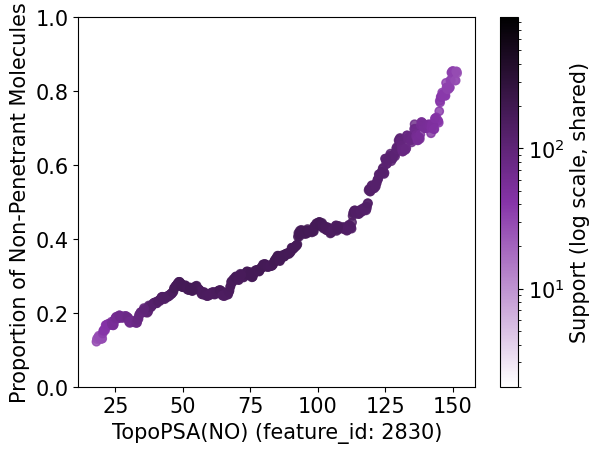

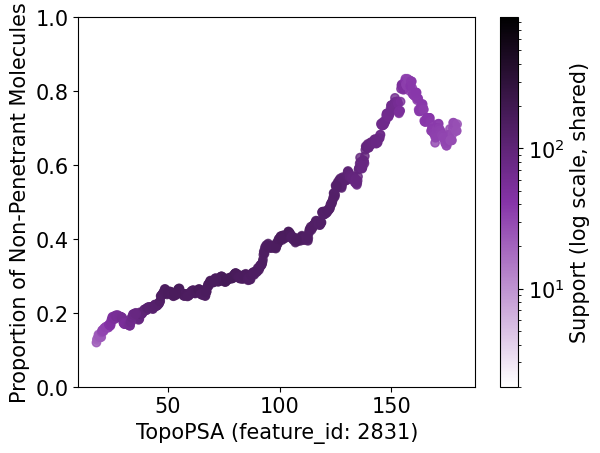

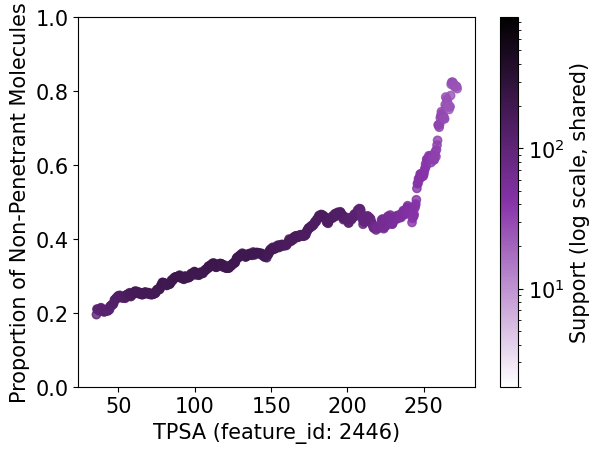

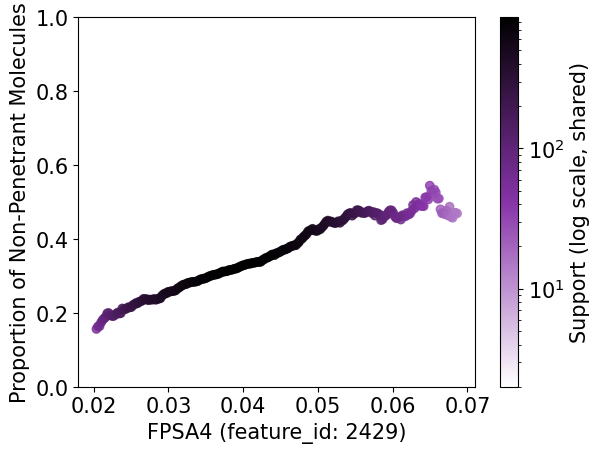

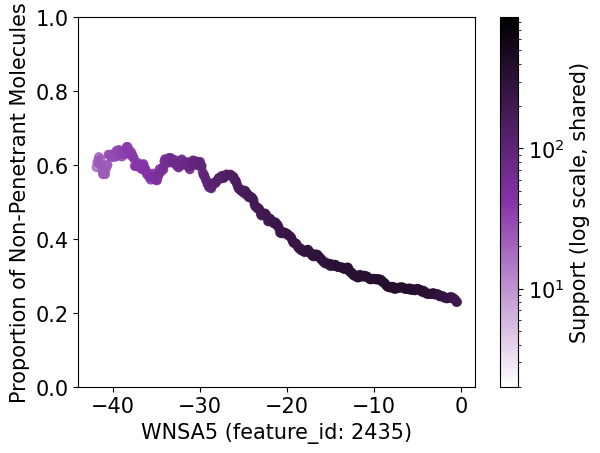

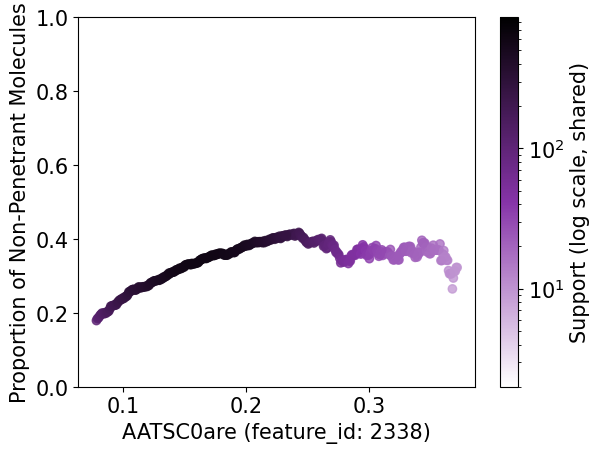

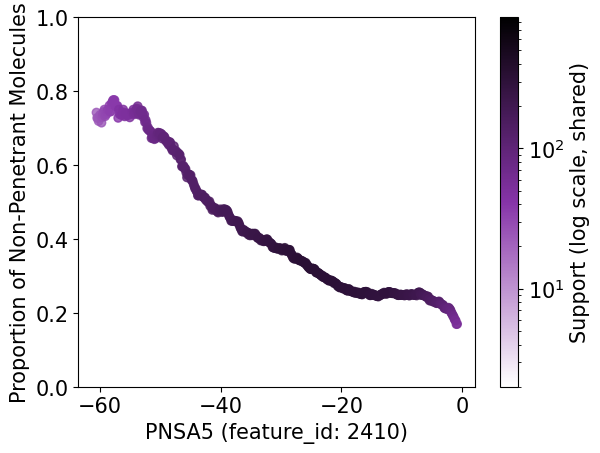

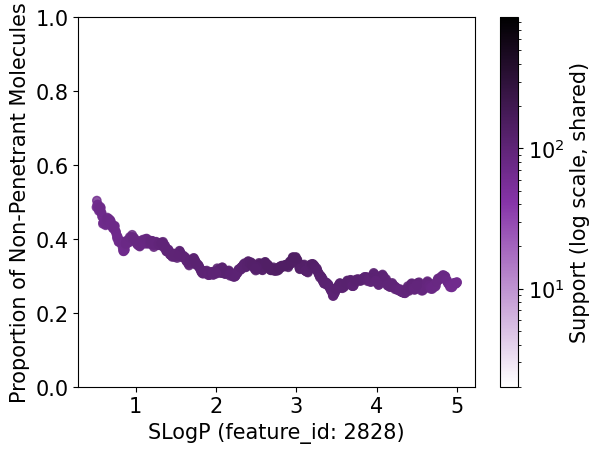

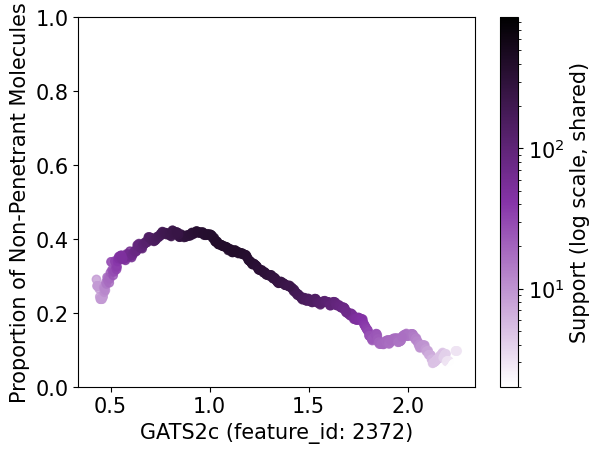

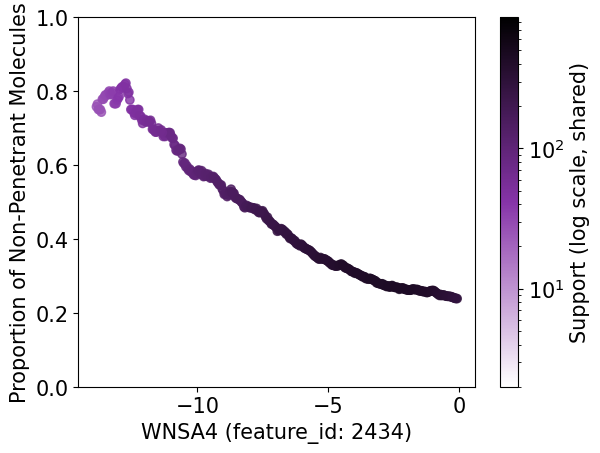

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, LogNorm

# Precompute global instance range
all_instances = []

for col in l_cols:
    for step in range(100):
        feature_max = np.max(X_all[:, [col]])
        feature_min = np.min(X_all[:, [col]])
        feature_range = feature_max - feature_min
        bins = np.arange(feature_min + (feature_range * step) / 1000,
                         feature_max, feature_range / 10)
        bin_indices = np.digitize(np.array(X_all[:, [col]]), bins, right=False)

        for i in range(1, len(bins)):
            in_bin = bin_indices == i
            in_bin = [x for xs in in_bin for x in xs]
            count = np.sum(np.array(in_bin).astype(int))
            if count > 30:
                all_instances.append(np.sum(bbb_class[in_bin]))


global_min = max(1, np.min(all_instances))
global_max = np.max(all_instances)

print(f"Global log scale range: {global_min:.1f} – {global_max:.1f}")


skyblue_cmap = LinearSegmentedColormap.from_list(
    'skyblue_custom',
    ['#FFFFFF', colors[3],'black'] # cceeff
)
norm = LogNorm(vmin=global_min, vmax=global_max)

n_bbb_np = np.sum(bbb_class == 1)


for col in l_cols: 
    for step in range(100):

        feature_max = np.max(X_all[:, [col]])
        feature_min = np.min(X_all[:, [col]])
        feature_range = feature_max - feature_min
        bins = np.arange(feature_min + (feature_range * step) / 1000,
                         feature_max,
                         feature_range / 10)
        bin_indices = np.digitize(np.array(X_all[:, [col]]), bins, right=False)
        proportion_np, bins_available = [], []
        instances = []

        for i in range(1, len(bins)):
            in_bin = bin_indices == i
            in_bin = [x for xs in in_bin for x in xs]
            if np.sum(np.array(in_bin).astype(int)) > 30:
                avg = bbb_class[in_bin].mean()
                instances.append(np.sum(bbb_class[in_bin]))
                proportion_np.append(avg)
                bins_available.append(bins[i])

        instances_arr = np.array(instances)
        color_based_on_support = [skyblue_cmap(norm(n)) for n in instances_arr]

        plt.scatter(bins_available, proportion_np, color=color_based_on_support, alpha=0.8)
        plt.xlabel(f'{list(X_full_no_nan.columns)[col]} (feature_id: {col})')
        plt.ylabel('Proportion of Non-Penetrant Molecules')
        plt.ylim((0, 1))

    # Shared log-scaled colorbar
    sm = cm.ScalarMappable(cmap=skyblue_cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm)
    cbar.set_label('Support (log scale, shared)')
    
    plt.savefig(f'../model_evaluation/{ds}/feature_ratios/feature_ratios_{list(X_full_no_nan.columns)[col]}.png', dpi=300)
    plt.show()
    plt.close()


Global log scale range: 2.0 – 864.0


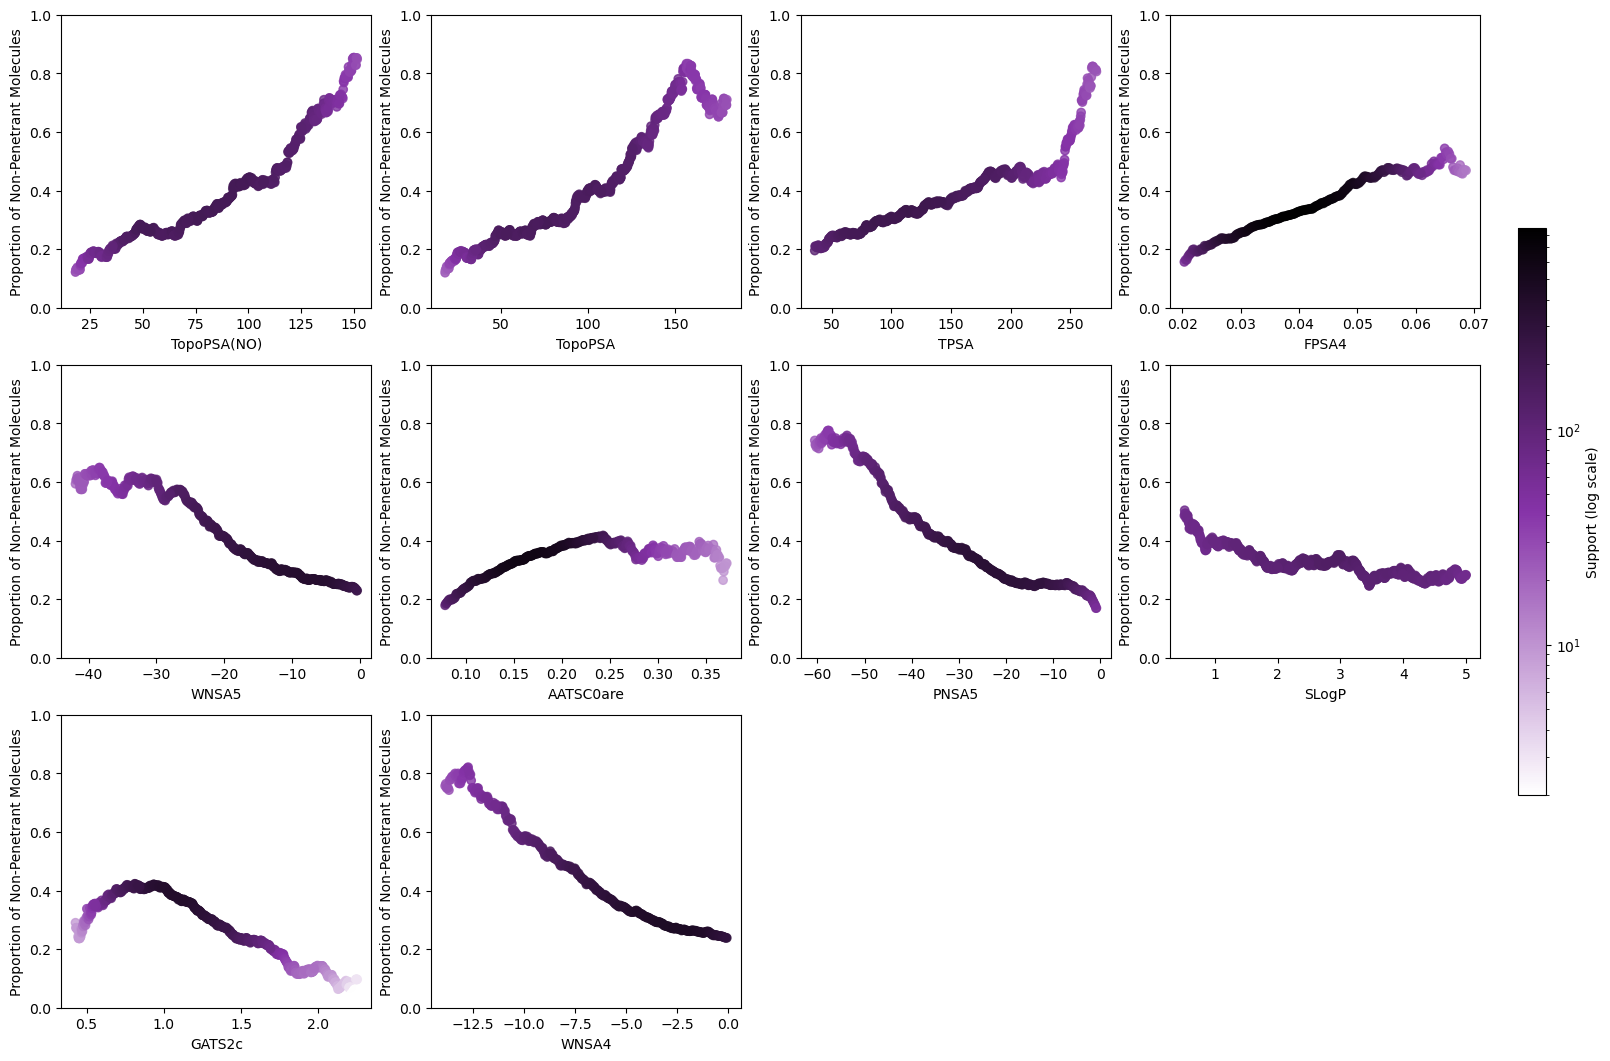

/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/50964833.py:113: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plot_feature_panels(l_cols[subset_indices], 3, 'Selected Feature Ratios', f'../model_evaluation/{ds}/feature_ratios/selected_features.png')


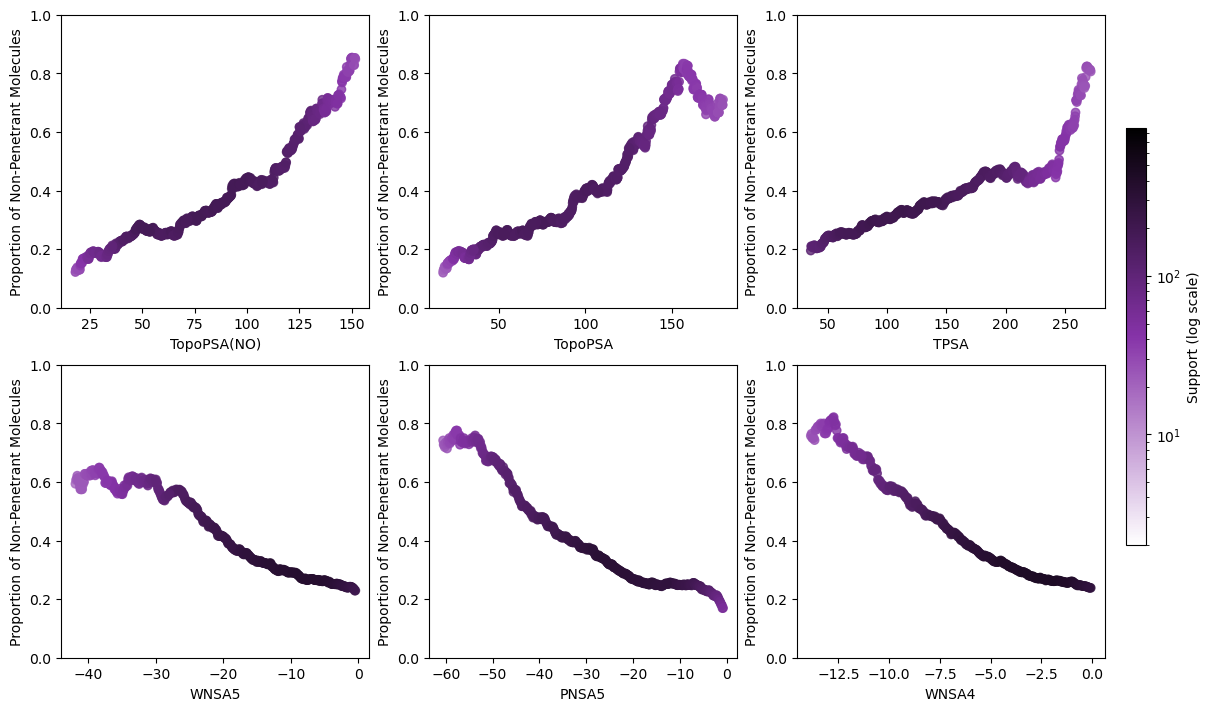

In [9]:
# TODO: CHECK THAT THIS IS WORKING WELL!! - FIX FOR Full feature list. 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, LogNorm

plt.rcParams.update({'font.size': 10})

# --- 1. Compute global instance range across all features ---
all_instances = []

for col in l_cols:
    for step in range(100):
        feature_max = np.max(X_all[:, [col]])
        feature_min = np.min(X_all[:, [col]])
        feature_range = feature_max - feature_min
        bins = np.arange(feature_min + (feature_range * step) / 1000,
                         feature_max,
                         feature_range / 10)
        bin_indices = np.digitize(np.array(X_all[:, [col]]), bins, right=False)

        for i in range(1, len(bins)):
            in_bin = bin_indices == i
            in_bin = [x for xs in in_bin for x in xs]
            count = np.sum(np.array(in_bin).astype(int))
            if count > 30:
                all_instances.append(np.sum(bbb_class[in_bin]))

global_min = max(1, np.min(all_instances))
global_max = np.max(all_instances)
print(f"Global log scale range: {global_min:.1f} – {global_max:.1f}")

# --- 2. Shared colormap and normalization ---
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_cmap',
    ['#FFFFFF', colors[3],'black'] # cceeff
)
norm = LogNorm(vmin=global_min, vmax=global_max)

# --- 3. Define reusable plotting function ---


# classification plots: 
def plot_feature_panels(feature_indices, n_cols, title, save_path):
    n_features = len(feature_indices)
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), constrained_layout=True)
    axes = axes.flatten()

    for idx, col in enumerate(feature_indices):
        ax = axes[idx]
        all_proportion_np, all_bins_available, all_instances = [], [], []

        for step in range(100):
            feature_max = np.max(X_all[:, [col]])
            feature_min = np.min(X_all[:, [col]])
            feature_range = feature_max - feature_min
            bins = np.arange(feature_min + (feature_range * step) / 1000,
                             feature_max,
                             feature_range / 10)
            bin_indices = np.digitize(np.array(X_all[:, [col]]), bins, right=False)

            proportion_np, bins_available, instances = [], [], []

            for i in range(1, len(bins)):
                in_bin = bin_indices == i
                in_bin = [x for xs in in_bin for x in xs]
                if np.sum(np.array(in_bin).astype(int)) > 30:
                    avg = bbb_class[in_bin].mean()
                    instances.append(np.sum(bbb_class[in_bin]))
                    proportion_np.append(avg)
                    bins_available.append(bins[i])

            if len(instances) > 0:
                all_proportion_np.extend(proportion_np)
                all_bins_available.extend(bins_available)
                all_instances.extend(instances)

        # color according to shared log scale
        instances_arr = np.array(all_instances)
        if len(instances_arr) > 0:
            color_based_on_support = [custom_cmap(norm(n)) for n in instances_arr]
            ax.scatter(all_bins_available, all_proportion_np, color=color_based_on_support, alpha=0.8)

        ax.set_xlabel(f'{list(X_full_no_nan.columns)[col]}')
        ax.set_ylabel('Proportion of Non-Penetrant Molecules')
        ax.set_ylim((0, 1))

    # Remove any unused subplots
    for ax in axes[n_features:]:
        fig.delaxes(ax)

    # Add shared colorbar
    sm = cm.ScalarMappable(cmap=skyblue_cmap, norm=norm)
    sm.set_array([])
    # cbar = fig.colorbar(sm, ax=axes, shrink=0.8, orientation='vertical', label='Support (log scale)')
    cbar = fig.colorbar(sm, ax=axes, location='right', pad=0.02, fraction=0.02)
    cbar.set_label('Support (log scale)')

    # plt.suptitle(title, fontsize=16)
    # plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(save_path, dpi=300) #, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# --- 4. Generate both figures ---
plot_feature_panels(l_cols[:10], 4,'All 10 Feature Ratios', f'../model_evaluation/{ds}/feature_ratios/all_features.png')

# Example subset: only features 0, 3, 5, 8
subset_indices = [0, 1, 2, 4, 6, 9]
plot_feature_panels(l_cols[subset_indices], 3, 'Selected Feature Ratios', f'../model_evaluation/{ds}/feature_ratios/selected_features.png')


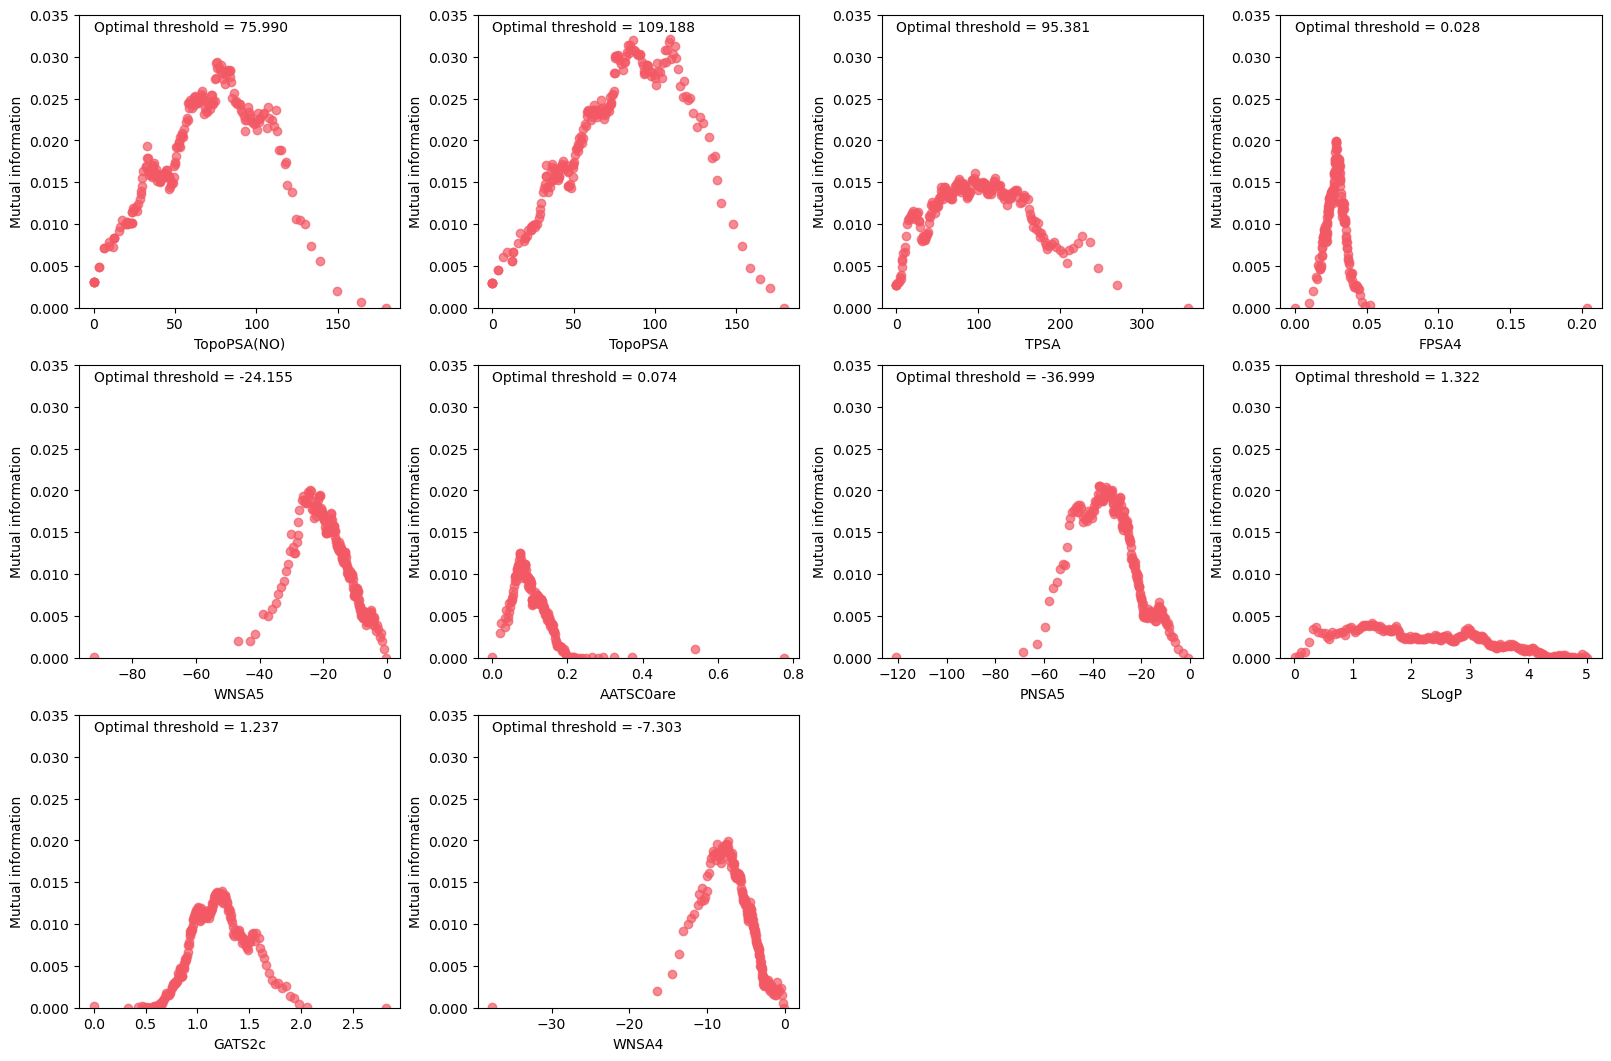

In [10]:
import numpy as np
from sklearn.metrics import roc_curve
import numpy as np
from sklearn.metrics import mutual_info_score

def threshold_mutual_information(feature, y, bins=200):

    thresholds = np.quantile(feature, np.linspace(0, 1, bins))
    
    MIs = []
    for t in thresholds:
        rule = (feature > t).astype(int)
        MI = mutual_info_score(rule, y)
        MIs.append(MI)

    return thresholds, MIs


def plot_optimal_mi_panels(df, feature_indices, bbb_class, n_cols, save_path):
    n_features = len(feature_indices)
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), constrained_layout=True)
    axes = axes.flatten()

    for idx, col in enumerate(feature_indices):
        ax = axes[idx]

        feature = np.array(df.iloc[:, col])

        thresholds, MIs = threshold_mutual_information(feature, bbb_class)
        
        best_idx = np.argmax(MIs)

        ax.scatter(thresholds, MIs, color=colors[0], alpha=0.7)
        ax.text(np.min(feature),0.033,f'Optimal threshold = {thresholds[best_idx]:.3f}')

        ax.set_xlabel(f'{list(X_full_no_nan.columns)[col]}')
        ax.set_ylabel('Mutual information')
        ax.set_ylim((0, 0.035))

    # Remove any unused subplots
    for ax in axes[n_features:]:
        fig.delaxes(ax)

    # plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(save_path, dpi=300) #, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    return 

plot_optimal_mi_panels(X_full_no_nan, l_cols, bbb_class, 4, f'../model_evaluation/{ds}/mutual_information_all.png')



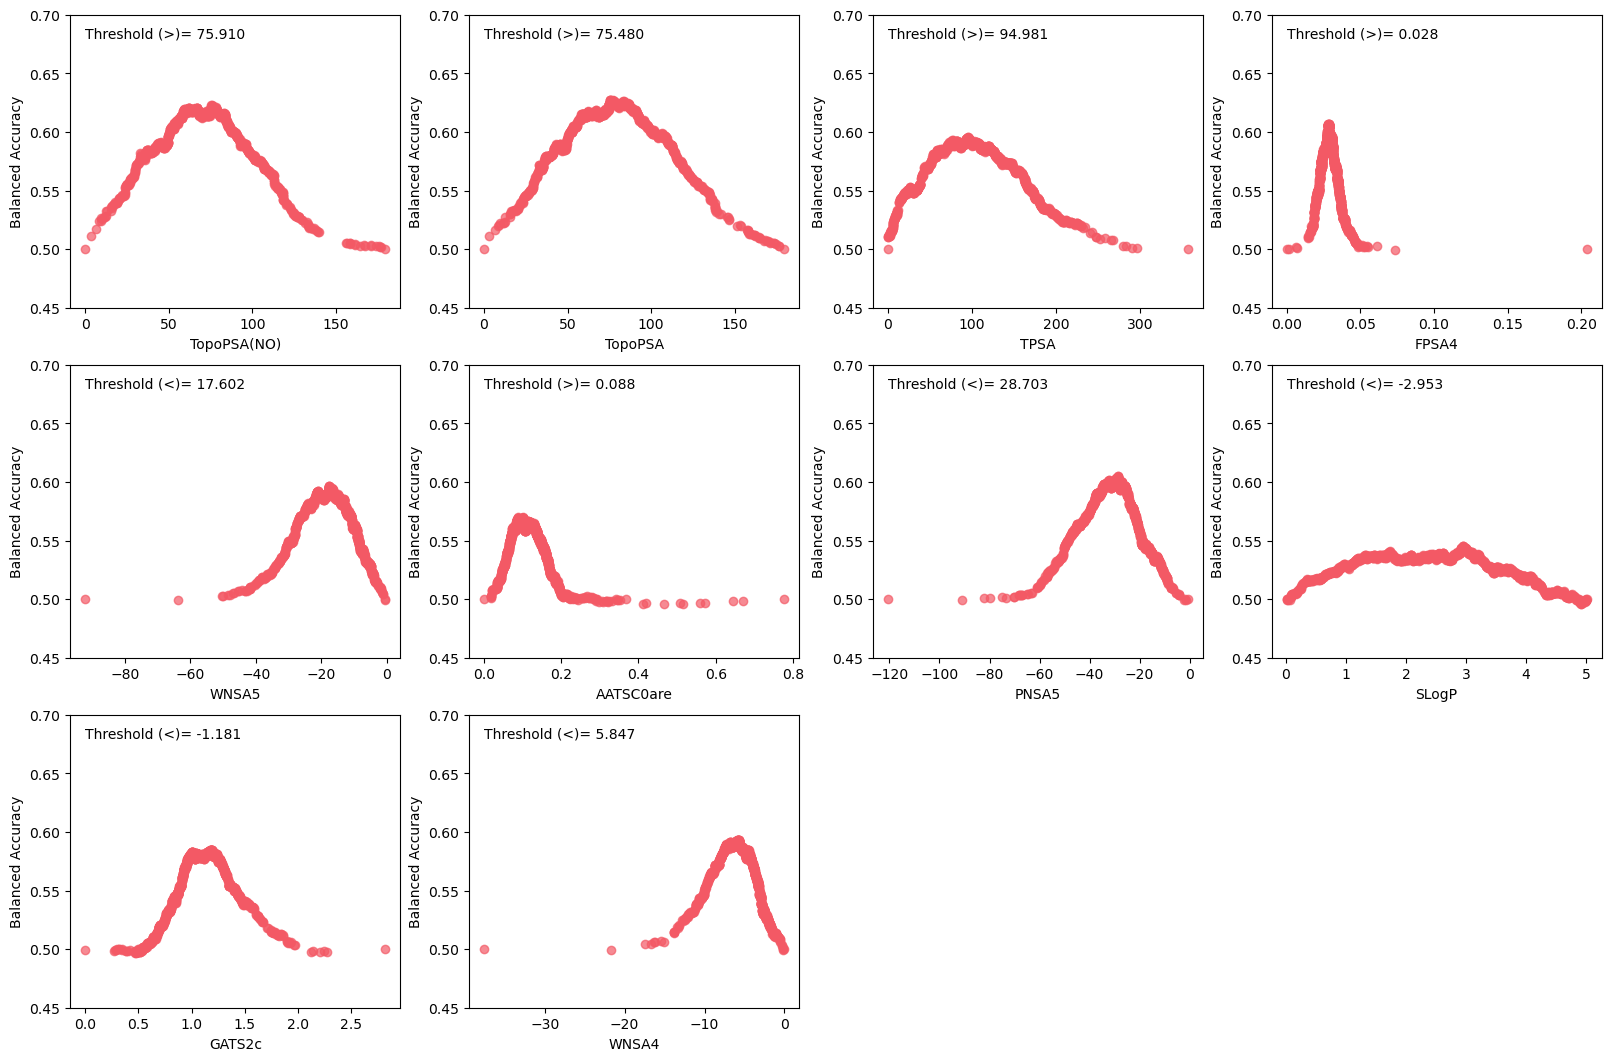

In [11]:
import numpy as np
from sklearn.metrics import roc_curve
import numpy as np
from sklearn.metrics import mutual_info_score


# this is balanced accuracy
def optimal_threshold_ba(feature, y, min_=False):
    """
    Returns the threshold t that maximizes Youden's J = TPR - FPR.
    feature: array-like (continuous feature)
    y: array-like (binary labels)
    """
    if np.max(feature) <0: 
        min_=True

    fpr_positive, tpr_positive, thresholds_positive = roc_curve(y, feature)
    J_positive = (tpr_positive-fpr_positive+1)/2

    fpr_negative, tpr_negative, thresholds_negative = roc_curve(y, -1*feature)
    J_negative = (tpr_negative-fpr_negative+1)/2

    if np.max(J_positive)>np.max(J_negative): 
        best_idx = np.argmax(J_positive)
        thresholds=thresholds_positive
        J = J_positive
        direction='>'
    else: 
        best_idx = np.argmax(J_negative)
        thresholds=thresholds_negative
        J = J_negative
        direction='<'

    return thresholds, J, best_idx, direction




def plot_optimal_ba_panels(df, feature_indices, bbb_class, n_cols, save_path):
    n_features = len(feature_indices)
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), constrained_layout=True)
    axes = axes.flatten()

    for idx, col in enumerate(feature_indices):
        ax = axes[idx]

        feature = np.array(df.iloc[:, col])

        thresholds, Js, best_idx, direction = optimal_threshold_ba(feature, bbb_class)

        if direction == '>':
            ax.scatter(thresholds, Js, color=colors[0], alpha=0.7)
            ax.text(np.min(feature),0.68,f'Threshold ({direction})= {thresholds[best_idx]:.3f}')
        else: 
            ax.scatter(-1*thresholds, Js, color=colors[0], alpha=0.7)
            ax.text(np.min(feature),0.68,f'Threshold ({direction})= {thresholds[best_idx]:.3f}')

        ax.set_xlabel(f'{list(X_full_no_nan.columns)[col]}')
        ax.set_ylabel('Balanced Accuracy')
        ax.set_ylim((0.45, 0.7))

    # Remove any unused subplots
    for ax in axes[n_features:]:
        fig.delaxes(ax)

    # plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(save_path, dpi=300) #, bbox_inches='tight')
    plt.show()
    plt.close(fig)


plot_optimal_ba_panels(X_full_no_nan, l_cols, bbb_class, 4, f'../model_evaluation/{ds}/balanced_accuracy_thresholds_all.png')



In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
import numpy as np
from math import log2
import itertools
from sklearn.metrics import mutual_info_score




def optimal_threshold_mutual_information(feature, y, bins=200):
    """
    feature: continuous array
    y: binary labels
    bins: number of candidate thresholds tested
    """
    # candidate thresholds as quantiles
    thresholds = np.quantile(feature, np.linspace(0, 1, bins))
    
    MIs = []
    for t in thresholds:
        rule = (feature > t).astype(int)
        MI = mutual_info_score(rule, y)
        MIs.append(MI)

    plt.scatter(thresholds, MIs)
    plt.show()
    
    best_idx = np.argmax(MIs)
    
    return thresholds[best_idx], MIs[best_idx]


def optimal_combinations_mi(all_features, y, bins=5):

    all_thresholds = []
    for feature in all_features: 
        thresholds = np.quantile(feature, np.linspace(0, 1, bins))
        all_thresholds.append(thresholds)
        
    all_combs = itertools.product(*all_thresholds)
    all_combs_lst = list(all_combs)
    
    MIs = []
    for t in all_combs_lst:
        combined_rules = 1
        for feature_id, feature in enumerate(all_features): 
            feature_rule_val = (np.array(feature) > t[feature_id]).astype(int)
            combined_rules *= feature_rule_val 
           
        MI = mutual_info_score(combined_rules, y)
        MIs.append(MI)

    # plt.scatter(range(len(all_combs_lst)), MIs)
    # plt.show()
    
    best_idx = np.argmax(MIs)

    # return np.array(all_combs_lst)[best_idx], np.array(MIs)[best_idx]
    return np.array(all_combs_lst)[np.array(MIs)>0.03], np.array(MIs)[np.array(MIs)>0.03]


# subset_feature_id = [int(top_features['feature_id'][si]) for si in subset_indices]

df = X_full_no_nan

subset_feature_id = [int(top_features['feature_id'][si]) for si in subset_indices]

all_features = [np.array(df.iloc[:, f]) for f in l_cols]
t, J = optimal_combinations_mi(all_features, bbb_class)

print(t, J)

/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/3752118813.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subset_feature_id = [int(top_features['feature_id'][si]) for si in subset_indices]


KeyboardInterrupt: 

[2721.  133.  242.   21.]
[0.27306137 0.57894737 0.65289256 0.76190476]


/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/704311386.py:74: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


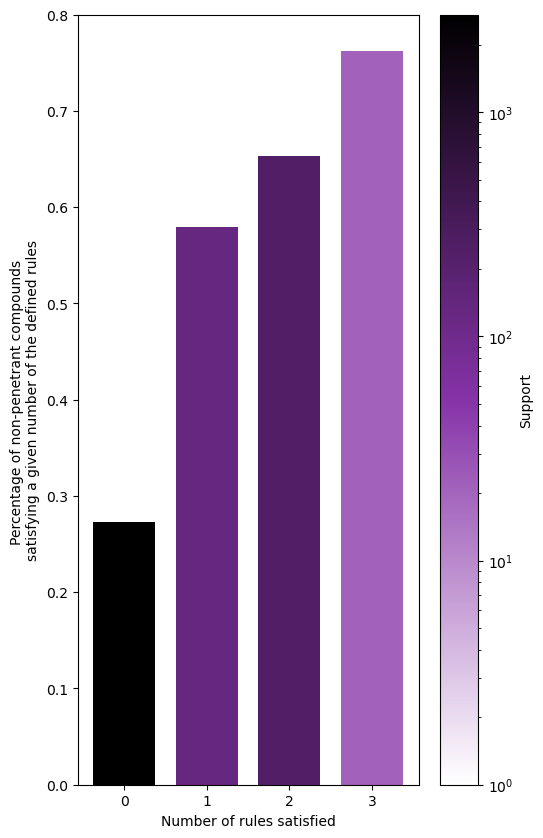

In [20]:

feature_ids_upper_bounded = []
feature_ids_lower_bounded = subset_feature_id[:3]
lower_bound = [110, 110, 250]

feature_ranges = []

n_criteria_met_nonpen = np.zeros((len(X_full_no_nan),))
n_criteria_met_pen = np.zeros((len(X_full_no_nan),))

for row in range(len(X_full_no_nan)): 
    for feature_id, feature in enumerate(feature_ids_lower_bounded): # 'nHBDon', 'nHBAcc'# 2050
        if (X_full_no_nan.iloc[row, feature] > lower_bound[feature_id]) and bbb_class[row] == 1: 
            n_criteria_met_nonpen[row] += 1
        if (X_full_no_nan.iloc[row, feature] > lower_bound[feature_id]) and bbb_class[row] == 0: 
            n_criteria_met_pen[row] += 1

    # for feature_id, feature in enumerate(feature_ids_upper_bounded):
    #     if (X_full_no_nan.iloc[row, feature] < upper_bound[feature_id]) and bbb_class[row] == 1: 
    #         n_criteria_met_nonpen[row] += 1
    #     if (X_full_no_nan.iloc[row, feature] < upper_bound[feature_id]) and bbb_class[row] == 0: 
    #         n_criteria_met_pen[row] += 1

total_features = len(feature_ids_lower_bounded) +len(feature_ids_upper_bounded) +1 
ratio, n_non_pen, n_pen = np.zeros((total_features,)), np.zeros((total_features,)), np.zeros((total_features,))
for n_criteria in range(total_features):
    try: 
        ratio[n_criteria] = list(n_criteria_met_nonpen).count(n_criteria)/(list(n_criteria_met_nonpen).count(n_criteria)+list(n_criteria_met_pen).count(n_criteria))
        n_non_pen[n_criteria], n_pen[n_criteria] = list(n_criteria_met_nonpen).count(n_criteria), list(n_criteria_met_pen).count(n_criteria)
    except: 
        ratio[n_criteria] = 0


n_bbb_np = np.sum((bbb_class==1).astype(int))
n_bbb_p = np.sum((bbb_class==0).astype(int))

n_non_pen[0] = n_bbb_np
n_pen[0] = n_bbb_p

for n_criteria in range(1, total_features):
    n_non_pen[0] -= n_non_pen[n_criteria] 
    n_pen[0] -= n_pen[n_criteria]
    sum_vals = n_non_pen+n_pen

ratio[0] = n_non_pen[0]/(n_non_pen[0] + n_pen[0])


custom_cmap = LinearSegmentedColormap.from_list(
    'custom_cmap',
    ['#FFFFFF', colors[3], 'black'])


# TODO: fix scaling
n_support = n_non_pen+n_pen

norm = LogNorm(vmin=1, vmax=np.max(n_support))

# print(np.min(np.array(n_non_pen)/n_bbb_np))
# print(np.max(np.array(n_non_pen)/n_bbb_np))

# cmap = cm.get_cmap('Spectral')
# print(ratio)
color_based_on_support = [custom_cmap(norm(n)) for n in n_support]
print(n_support)
print(n_non_pen/n_support)
plt.figure(figsize=(5.5,10))
plt.bar(range(len(ratio)), ratio[:], width=0.75, color=color_based_on_support) # #s=5, edgecolor="#6E94A8"
plt.xlabel('Number of rules satisfied')
plt.xticks(list(range(len(ratio))))
plt.ylabel('Percentage of non-penetrant compounds \nsatisfying a given number of the defined rules')


sm = cm.ScalarMappable(cmap=skyblue_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Support')

plt.savefig(f'../model_evaluation/{ds}/criteria_non_penetrant.png', dpi=300)

plt.show()